# Factor AI Lab 04 — robust PDV tracking v2

Version 1 showed a valuable failure: its velocity intervals were calibrated on average, but it detected **zero** ambiguous frames and its uncertainty did not identify the worst usable estimates. Version 2 keeps the residual-CNN idea and changes the training/evaluation design to target those failures.

The completed v1 and the user's eight-seed pre-test notebook are preserved as separate files. This notebook uses new data splits and a new locked-test identifier.

## Explain it like I am five

The ordinary tracker draws a line through the bright trail. The neural helper may nudge that line, attach an error bar, and raise a warning flag when the trail splits or disappears.

In v1, the helper never raised the flag. Rare confusing frames were overwhelmed by many ordinary frames. In v2, confusing examples appear more often during training and mistakes on them count more. A new ranking lesson also asks: “Which of these two answers is more likely to be wrong?”

## Frozen task definition

- **Decision:** determine when a PDV-derived speed trace may be used automatically and when it should be withheld for review or an additional measurement.
- **Observed:** voltage waveform and declared acquisition metadata.
- **Outputs:** speed magnitude, calibrated interval, and ambiguity probability at every STFT frame.
- **Baselines:** independent peak ridge and dynamic-programming ridge.
- **Candidate:** temporal residual CNN receiving the same spectrogram plus the baseline trace and peak prominence.
- **Splits:** independent training, tuning, calibration, and locked-test simulated shots.
- **Scientific boundary:** synthetic truth validates behavior only within this generator. It does not validate real PDV, material phase, or an instability mechanism.

In [1]:
import copy, platform, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import ShortTimeFFT
import torch
from torch import nn
import torch.nn.functional as F

sns.set_theme(style='whitegrid',context='notebook')
DEVICE=torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
FS=4e9; WAVELENGTH=1550e-9; N=1024; MAX_SPEED=1300.; N_BINS=96
T=np.arange(N)/FS; VGRID=np.linspace(0,MAX_SPEED,N_BINS)
OPEN_LOCKED_TEST=True
LOCKED_TEST_ID='pdv-robust-v2-seeds-40000-40063'
print(f'Python {platform.python_version()} | PyTorch {torch.__version__} | {DEVICE}')

Python 3.12.14 | PyTorch 2.14.0 | mps


## 1. Forward model and independent splits

The hidden velocity becomes Doppler phase and then detector voltage. Four nuisance regimes challenge the reconstruction. Dropout and comparable dual returns create evaluator-only ambiguity labels.

Version 2 oversamples dropout and dual-return shots **only in training**. Tuning and calibration remain balanced. The locked set uses entirely new seeds and stays inaccessible during development.

In [2]:
REGIMES=('nominal','low_snr','dropout','dual_return')

def smoothstep(x):
    x=np.clip(x,0,1); return x*x*(3-2*x)

def simulate(seed,regime):
    rng=np.random.default_rng(seed); u=np.linspace(0,1,N)
    speed=np.clip(rng.uniform(70,180)+rng.uniform(480,780)*smoothstep((u-rng.uniform(.08,.2))/rng.uniform(.5,.78))
                  +rng.uniform(15,65)*np.sin(2*np.pi*(rng.uniform(.7,1.7)*u+rng.random())),20,MAX_SPEED-180)
    amp=1+.2*np.sin(2*np.pi*(rng.uniform(.4,1.3)*u+rng.random()))
    sigma=.10; secondary=np.zeros(N); ambiguous=np.zeros(N,dtype=bool)
    if regime=='low_snr': sigma=.32
    if regime=='dropout':
        center=rng.uniform(.4,.75); width=rng.uniform(.025,.065)
        amp*=1-rng.uniform(.75,.98)*np.exp(-.5*((u-center)/width)**2)
        ambiguous=np.abs(u-center)<1.4*width
    if regime=='dual_return':
        center=rng.uniform(.35,.68); width=rng.uniform(.07,.14); envelope=np.exp(-.5*((u-center)/width)**2)
        other=np.clip(speed+rng.choice([-1,1])*rng.uniform(110,260),0,MAX_SPEED)
        phase2=2*np.pi*np.cumsum(2*other/WAVELENGTH)/FS+rng.uniform(0,2*np.pi)
        ratio=rng.uniform(.55,1.05)*envelope; secondary=ratio*np.cos(phase2)
        ambiguous=ratio>.55
    phase=2*np.pi*np.cumsum(2*speed/WAVELENGTH)/FS+rng.uniform(0,2*np.pi)
    drift=rng.uniform(.04,.16)*np.sin(2*np.pi*rng.uniform(3e6,18e6)*T+rng.random())
    voltage=amp*np.cos(phase)+secondary+drift+rng.normal(0,sigma,N)
    return {'seed':seed,'regime':regime,'voltage':voltage.astype('float32'),
            'speed':speed.astype('float32'),'ambiguous':ambiguous}

def balanced_split(first_seed,count):
    return [simulate(first_seed+i,REGIMES[i%4]) for i in range(count)]

# Twice as many ambiguous-regime shots in training; all evaluation splits stay balanced.
train_regimes=['nominal']*16+['low_snr']*16+['dropout']*32+['dual_return']*32
rng=np.random.default_rng(20260906); rng.shuffle(train_regimes)
train=[simulate(10000+i,r) for i,r in enumerate(train_regimes)]
tune=balanced_split(20000,32)
calibration=balanced_split(25000,32)
locked=balanced_split(40000,64)
print('shots:',len(train),'train,',len(tune),'tune,',len(calibration),'calibration,',len(locked),'locked')

shots: 96 train, 32 tune, 32 calibration, 64 locked


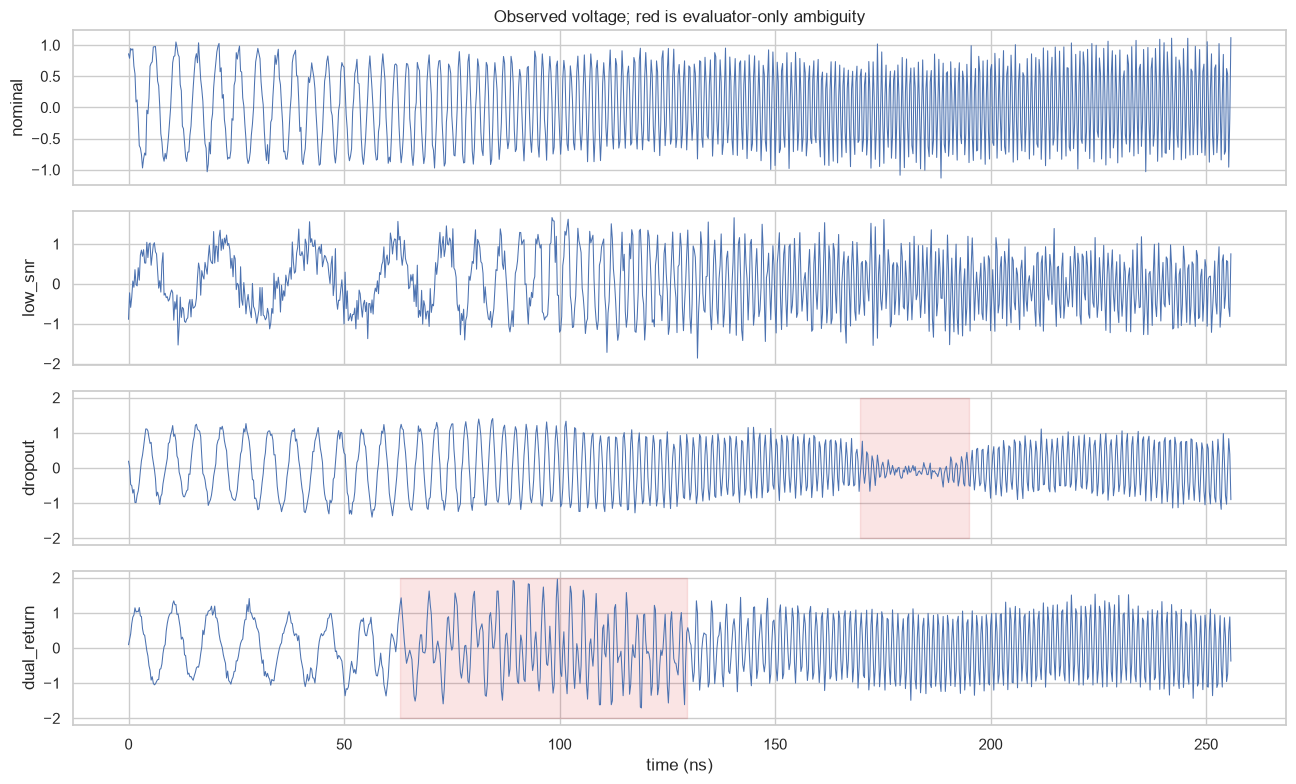

In [3]:
fig,axes=plt.subplots(4,1,figsize=(13,8),sharex=True)
for ax,regime in zip(axes,REGIMES):
    shot=next(s for s in tune if s['regime']==regime)
    ax.plot(T*1e9,shot['voltage'],linewidth=.75); ax.set_ylabel(regime)
    ax.fill_between(T*1e9,-2,2,where=shot['ambiguous'],color='tab:red',alpha=.12)
axes[-1].set_xlabel('time (ns)'); axes[0].set_title('Observed voltage; red is evaluator-only ambiguity')
plt.tight_layout(); plt.show()

## 2. Conventional estimators

The peak ridge chooses each frame independently. The dynamic-programming estimator rewards spectral brightness and penalizes jumps. Its penalty is chosen on tuning shots only. A selected penalty of zero is retained as a negative result rather than manually overridden.

In [4]:
STFT=ShortTimeFFT.from_window('hann',fs=FS,nperseg=96,noverlap=72,mfft=768,scale_to='magnitude')

def transform(shot):
    mag=np.abs(STFT.stft(shot['voltage'])); ft=STFT.t(N)
    keep=(ft>=0)&(ft<=T[-1]); mag=mag[:,keep]; ft=ft[keep]
    native=WAVELENGTH*STFT.f/2; usable=native<=MAX_SPEED
    spec=np.stack([np.interp(VGRID,native[usable],mag[usable,j]) for j in range(mag.shape[1])],axis=1)
    spec=np.clip((20*np.log10(spec/(spec.max()+1e-12)+1e-6)+60)/60,0,1).astype('float32')
    truth=np.interp(ft,T,shot['speed']).astype('float32')
    ambiguity=np.interp(ft,T,shot['ambiguous'].astype(float))>.35
    return spec,truth,ambiguity,ft

def peak_ridge(spec): return VGRID[np.argmax(spec,axis=0)]

def continuity_ridge(spec,jump_penalty=.035):
    bins,times=spec.shape; distance=np.abs(np.arange(bins)[:,None]-np.arange(bins)[None,:])
    score=np.empty_like(spec); back=np.zeros((bins,times),dtype=np.int16); score[:,0]=spec[:,0]
    for t in range(1,times):
        choices=score[:,t-1][None,:]-jump_penalty*distance
        back[:,t]=np.argmax(choices,axis=1); score[:,t]=spec[:,t]+choices[np.arange(bins),back[:,t]]
    path=np.empty(times,dtype=int); path[-1]=np.argmax(score[:,-1])
    for t in range(times-1,0,-1): path[t-1]=back[path[t],t]
    return VGRID[path]

def mae(pred,truth,mask=None):
    if mask is None: mask=np.ones_like(truth,dtype=bool)
    return np.mean(np.abs(pred[mask]-truth[mask]))

penalties=[0,.0025,.005,.01,.02,.035,.05,.08]
rows=[]
for penalty in penalties:
    errors=[]
    for shot in tune:
        spec,truth,amb,_=transform(shot); errors.append(mae(continuity_ridge(spec,penalty),truth,~amb))
    rows.append({'jump_penalty':penalty,'tune_MAE':np.mean(errors)})
baseline_search=pd.DataFrame(rows)
BEST_PENALTY=float(baseline_search.loc[baseline_search.tune_MAE.idxmin(),'jump_penalty'])
display(baseline_search.round(3)); print('Selected continuity penalty:',BEST_PENALTY)

,jump_penalty,tune_MAE
0,0.000,3.706
1,0.002,3.711
2,0.005,3.760
3,0.010,3.797
4,0.020,4.170
5,0.035,4.562
6,0.050,4.930
7,0.080,5.540


Selected continuity penalty: 0.0


## 3. Residual CNN with targeted failure training

The network has 98 inputs per time frame: 96 spectral bins, the normalized baseline velocity, and peak prominence. It predicts a bounded correction, positive uncertainty scale, and ambiguity logit.

Version 2 adds:

- **Class-weighted ambiguity loss:** rare ambiguous frames count approximately as much as all usable frames.
- **Ambiguous-regime oversampling:** dropout and dual-return shots appear twice as often in training.
- **Uncertainty ranking loss:** when one usable prediction has a larger error than another, its predicted sigma should also be larger.
- **Multi-task model selection:** the best epoch is selected using velocity, uncertainty, ranking, and ambiguity losses on tuning data, rather than velocity MAE alone.

In [5]:
class ResidualPDVCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.body=nn.Sequential(nn.Conv1d(N_BINS+2,64,5,padding=2),nn.GELU(),
                                nn.Conv1d(64,48,5,padding=2),nn.GELU(),
                                nn.Conv1d(48,24,3,padding=1),nn.GELU())
        self.head=nn.Conv1d(24,3,1)
    def forward(self,x,base):
        raw=self.head(self.body(x)); correction=140*torch.tanh(raw[:,0])
        mean=torch.clamp(base+correction,0,MAX_SPEED)
        sigma=3+F.softplus(raw[:,1])*45
        return mean,sigma,raw[:,2]

def tensors(shots):
    features=[]; bases=[]; truths=[]; ambiguities=[]
    for shot in shots:
        spec,truth,amb,_=transform(shot); base=continuity_ridge(spec,BEST_PENALTY).astype('float32')
        ordered=np.sort(spec,axis=0); prominence=(ordered[-1]-ordered[-2]).astype('float32')
        features.append(np.concatenate([spec,(base/MAX_SPEED)[None],prominence[None]],axis=0))
        bases.append(base); truths.append(truth); ambiguities.append(amb.astype('float32'))
    return tuple(torch.tensor(np.stack(v),device=DEVICE) for v in (features,bases,truths,ambiguities))

train_tensors=tensors(train); tune_tensors=tensors(tune)
positive=train_tensors[3].sum(); negative=train_tensors[3].numel()-positive
POS_WEIGHT=(negative/positive).detach()
AMBIGUITY_WEIGHT=1.0; RANKING_WEIGHT=.25
print('ambiguous frame fraction:',round(float(positive/train_tensors[3].numel()),3),
      '| positive class weight:',round(float(POS_WEIGHT),2))

def component_losses(model,batch,make_pairs=True):
    x,b,y,a=batch; mean,sigma,logit=model(x,b); usable=(1-a)
    nll=((.5*((y-mean)/sigma)**2+torch.log(sigma))*usable).sum()/usable.sum()
    ambiguity=F.binary_cross_entropy_with_logits(logit,a,pos_weight=POS_WEIGHT)
    valid=usable.bool().flatten(); sf=sigma.flatten()[valid]; ef=(y-mean).abs().detach().flatten()[valid]
    if make_pairs:
        # Deterministic adjacent pairing after a seed-controlled permutation.
        perm=torch.randperm(len(sf),device=sf.device); half=len(sf)//2
        i,j=perm[:half],perm[half:2*half]; target=torch.sign(ef[i]-ef[j]); informative=target!=0
        ranking=F.margin_ranking_loss(sf[i][informative],sf[j][informative],target[informative],margin=.25)
    else:
        ranking=torch.zeros((),device=DEVICE)
    total=nll+AMBIGUITY_WEIGHT*ambiguity+RANKING_WEIGHT*ranking
    return total,nll,ambiguity,ranking,mean,sigma,logit

def train_model(seed,epochs=800):
    torch.manual_seed(seed); model=ResidualPDVCNN().to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=1e-3)
    best={'objective':np.inf,'state':None,'mae':np.inf}; history=[]
    for epoch in range(1,epochs+1):
        model.train(); opt.zero_grad(); total,nll,amb_loss,rank,*_=component_losses(model,train_tensors,True)
        total.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            td,tn,ta,tr,mean,_,_=component_losses(model,tune_tensors,False)
            x,b,y,a=tune_tensors; tune_mae=((mean-y).abs()*(1-a)).sum()/(1-a).sum()
            # Pairwise rank loss is diagnostic during training; tuning objective uses stable NLL+BCE.
            objective=tn+AMBIGUITY_WEIGHT*ta
        if objective.item()<best['objective']:
            best={'objective':objective.item(),'state':copy.deepcopy(model.state_dict()),'mae':tune_mae.item()}
        if epoch==1 or epoch%20==0:
            history.append({'epoch':epoch,'tune_MAE':tune_mae.item(),'tune_objective':objective.item(),
                            'train_ambiguity_loss':amb_loss.item(),'train_rank_loss':rank.item()})
    model.load_state_dict(best['state']); return model,pd.DataFrame(history),best

runs=[]; started=time.perf_counter()
for seed in (41,42,43,44,45,46,47,48):
    model,history,score=train_model(seed); runs.append({'seed':seed,'model':model,'history':history,**score})
    print('seed',seed,'tune MAE',round(score['mae'],2),'objective',round(score['objective'],3))
best=min(runs,key=lambda r:r['objective'])
print('selected seed:',best['seed'],'| training seconds:',round(time.perf_counter()-started,1))

ambiguous frame fraction: 0.09 | positive class weight: 10.1


seed 41 tune MAE 3.99 objective 2.789


seed 42 tune MAE 3.86 objective 2.657


seed 43 tune MAE 3.85 objective 2.69


seed 44 tune MAE 3.96 objective 2.736


seed 45 tune MAE 3.82 objective 2.778


seed 46 tune MAE 4.04 objective 2.824


seed 47 tune MAE 3.88 objective 2.788


seed 48 tune MAE 4.08 objective 2.764
selected seed: 42 | training seconds: 29.9


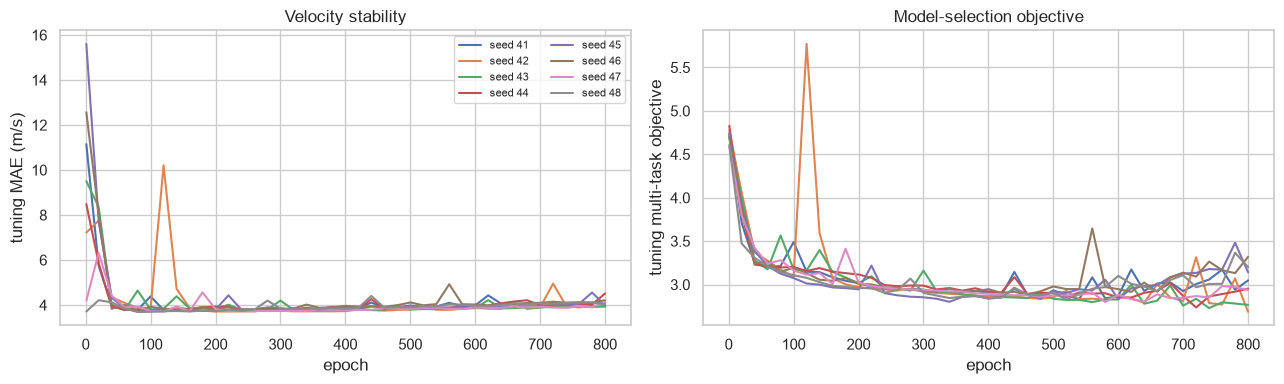

In [6]:
fig,axes=plt.subplots(1,2,figsize=(13,4))
for run in runs:
    axes[0].plot(run['history'].epoch,run['history'].tune_MAE,label=f"seed {run['seed']}")
    axes[1].plot(run['history'].epoch,run['history'].tune_objective,label=f"seed {run['seed']}")
axes[0].set(xlabel='epoch',ylabel='tuning MAE (m/s)',title='Velocity stability')
axes[1].set(xlabel='epoch',ylabel='tuning multi-task objective',title='Model-selection objective')
axes[0].legend(ncol=2,fontsize=8); plt.tight_layout(); plt.show()

## 4. Calibration and diagnostic dashboard

The tuning set selected the architecture state. A separate calibration set now determines:

- one conservative sigma multiplier based on the worst calibrated regime;
- an ambiguity threshold that maximizes recall while keeping usable-frame false alarms at or below 20%.

This keeps threshold fitting separate from model selection. The locked set is still closed.

In [7]:
def evaluate_shots(shots,model):
    shot_rows=[]; frame_rows=[]; examples={}; model.eval()
    for shot in shots:
        spec,truth,amb,ft=transform(shot); peak=peak_ridge(spec).astype('float32')
        cont=continuity_ridge(spec,BEST_PENALTY).astype('float32')
        ordered=np.sort(spec,axis=0); prominence=(ordered[-1]-ordered[-2]).astype('float32')
        xin=np.concatenate([spec,(cont/MAX_SPEED)[None],prominence[None]],axis=0)
        with torch.no_grad():
            mean,sigma,logit=model(torch.tensor(xin[None],device=DEVICE),
                torch.tensor(cont[None],device=DEVICE,dtype=torch.float32))
        mean=mean.cpu().numpy()[0]; sigma=sigma.cpu().numpy()[0]
        prob=torch.sigmoid(logit).cpu().numpy()[0]; usable=~amb
        for name,pred in [('peak',peak),('continuity',cont),('residual CNN',mean)]:
            err=pred[usable]-truth[usable]
            shot_rows.append({'shot':shot['seed'],'regime':shot['regime'],'method':name,
                'MAE':np.mean(np.abs(err)),'bias':np.mean(err),'p95_abs_error':np.quantile(np.abs(err),.95)})
        for j in range(len(truth)):
            frame_rows.append({'shot':shot['seed'],'regime':shot['regime'],'time_ns':ft[j]*1e9,
                'truth':truth[j],'peak':peak[j],'continuity':cont[j],'cnn':mean[j],
                'raw_sigma':sigma[j],'ambiguity_prob':prob[j],'ambiguous':bool(amb[j])})
        examples.setdefault(shot['regime'],{'time':ft,'truth':truth,'amb':amb,'continuity':cont,
            'cnn':mean,'raw_sigma':sigma,'ambiguity_prob':prob})
    return pd.DataFrame(shot_rows),pd.DataFrame(frame_rows),examples

def risk_curve(frames):
    usable=frames.loc[~frames.ambiguous].copy(); usable['abs_error']=(usable.cnn-usable.truth).abs()
    ordered=usable.sort_values('calibrated_sigma'); rows=[]
    for coverage in (1.0,.95,.90,.80,.70,.50):
        kept=ordered.iloc[:max(1,int(np.ceil(coverage*len(ordered))))]
        rows.append({'retained_fraction':coverage,'abstained_fraction':1-coverage,
            'retained_MAE':kept.abs_error.mean(),'retained_p95':kept.abs_error.quantile(.95)})
    return pd.DataFrame(rows)

def ambiguity_metrics(frames,threshold):
    pos=frames.ambiguous
    return {'recall':float((frames.loc[pos,'ambiguity_prob']>=threshold).mean()),
            'false_confidence':float((frames.loc[pos,'ambiguity_prob']<threshold).mean()),
            'usable_false_alarm':float((frames.loc[~pos,'ambiguity_prob']>=threshold).mean())}

cal_shots,cal_frames,cal_examples=evaluate_shots(calibration,best['model'])
scales=[]
for regime,g in cal_frames.loc[~cal_frames.ambiguous].groupby('regime'):
    ratio=np.abs(g.cnn-g.truth)/np.maximum(g.raw_sigma,1e-6)
    scales.append({'regime':regime,'sigma_scale':np.quantile(ratio,.95)/1.96})
scale_table=pd.DataFrame(scales)
SIGMA_SCALE=float(scale_table.sigma_scale.max())
cal_frames['calibrated_sigma']=cal_frames.raw_sigma*SIGMA_SCALE

threshold_rows=[]
for threshold in np.linspace(.01,.99,99):
    threshold_rows.append({'threshold':threshold,**ambiguity_metrics(cal_frames,threshold)})
threshold_search=pd.DataFrame(threshold_rows)
feasible=threshold_search.loc[threshold_search.usable_false_alarm<=.20]
chosen=feasible.sort_values(['recall','threshold'],ascending=[False,False]).iloc[0]
AMBIGUITY_THRESHOLD=float(chosen.threshold)
print('Worst-regime sigma scale:',round(SIGMA_SCALE,3))
print('Calibrated ambiguity threshold:',round(AMBIGUITY_THRESHOLD,2))
display(scale_table.round(3))

Worst-regime sigma scale: 1.022
Calibrated ambiguity threshold: 0.6


,regime,sigma_scale
0,dropout,0.956
1,dual_return,1.022
2,low_snr,1.013
3,nominal,0.956


In [8]:
cal_velocity=cal_shots.groupby(['regime','method'])[['MAE','bias','p95_abs_error']].mean().round(2)
cal_interval=(cal_frames.loc[~cal_frames.ambiguous].assign(
    covered=lambda d:np.abs(d.cnn-d.truth)<=1.96*d.calibrated_sigma,
    width_95=lambda d:2*1.96*d.calibrated_sigma)
    .groupby('regime')[['covered','width_95']].mean().rename(columns={'covered':'coverage_95'}).round(3))
cal_ambiguity=pd.DataFrame([ambiguity_metrics(cal_frames,AMBIGUITY_THRESHOLD)]).round(3)
cal_risk=risk_curve(cal_frames)
print('Calibration velocity errors'); display(cal_velocity)
print('Calibration intervals by regime'); display(cal_interval)
print('Calibration ambiguity behavior'); display(cal_ambiguity)
print('Calibration risk/coverage'); display(cal_risk.round(3))

Calibration velocity errors


MAE  bias  p95_abs_error
regime      method                                 
dropout     continuity    3.75  0.31           7.30
            peak          3.75  0.31           7.30
            residual CNN  3.87 -0.07           8.37
dual_return continuity    3.77 -0.48           8.64
            peak          3.77 -0.48           8.64
            residual CNN  3.96 -0.51           9.22
low_snr     continuity    3.74  0.04           7.91
            peak          3.74  0.08           7.91
            residual CNN  3.78 -0.97           8.38
nominal     continuity    3.60 -0.03           7.22
            peak          3.60 -0.03           7.22
            residual CNN  3.86 -0.47           8.15

Calibration intervals by regime


,coverage_95,width_95
regime,,
dropout,0.960,17.816000
dual_return,0.950,17.798000
low_snr,0.951,17.511999
nominal,0.977,17.811001


Calibration ambiguity behavior


,recall,false_confidence,usable_false_alarm
0,0.835,0.165,0.193


Calibration risk/coverage


,retained_fraction,abstained_fraction,retained_MAE,retained_p95
0,1.00,0.00,3.866,8.575
1,0.95,0.05,3.758,8.276
2,0.90,0.10,3.739,8.242
3,0.80,0.20,3.723,8.237
4,0.70,0.30,3.673,8.240
5,0.50,0.50,3.696,8.173


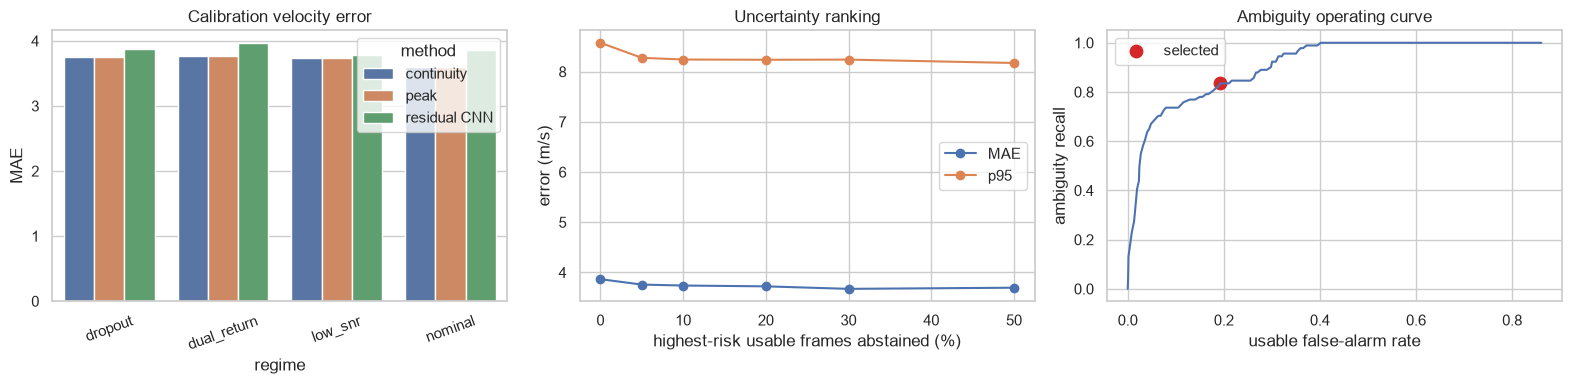

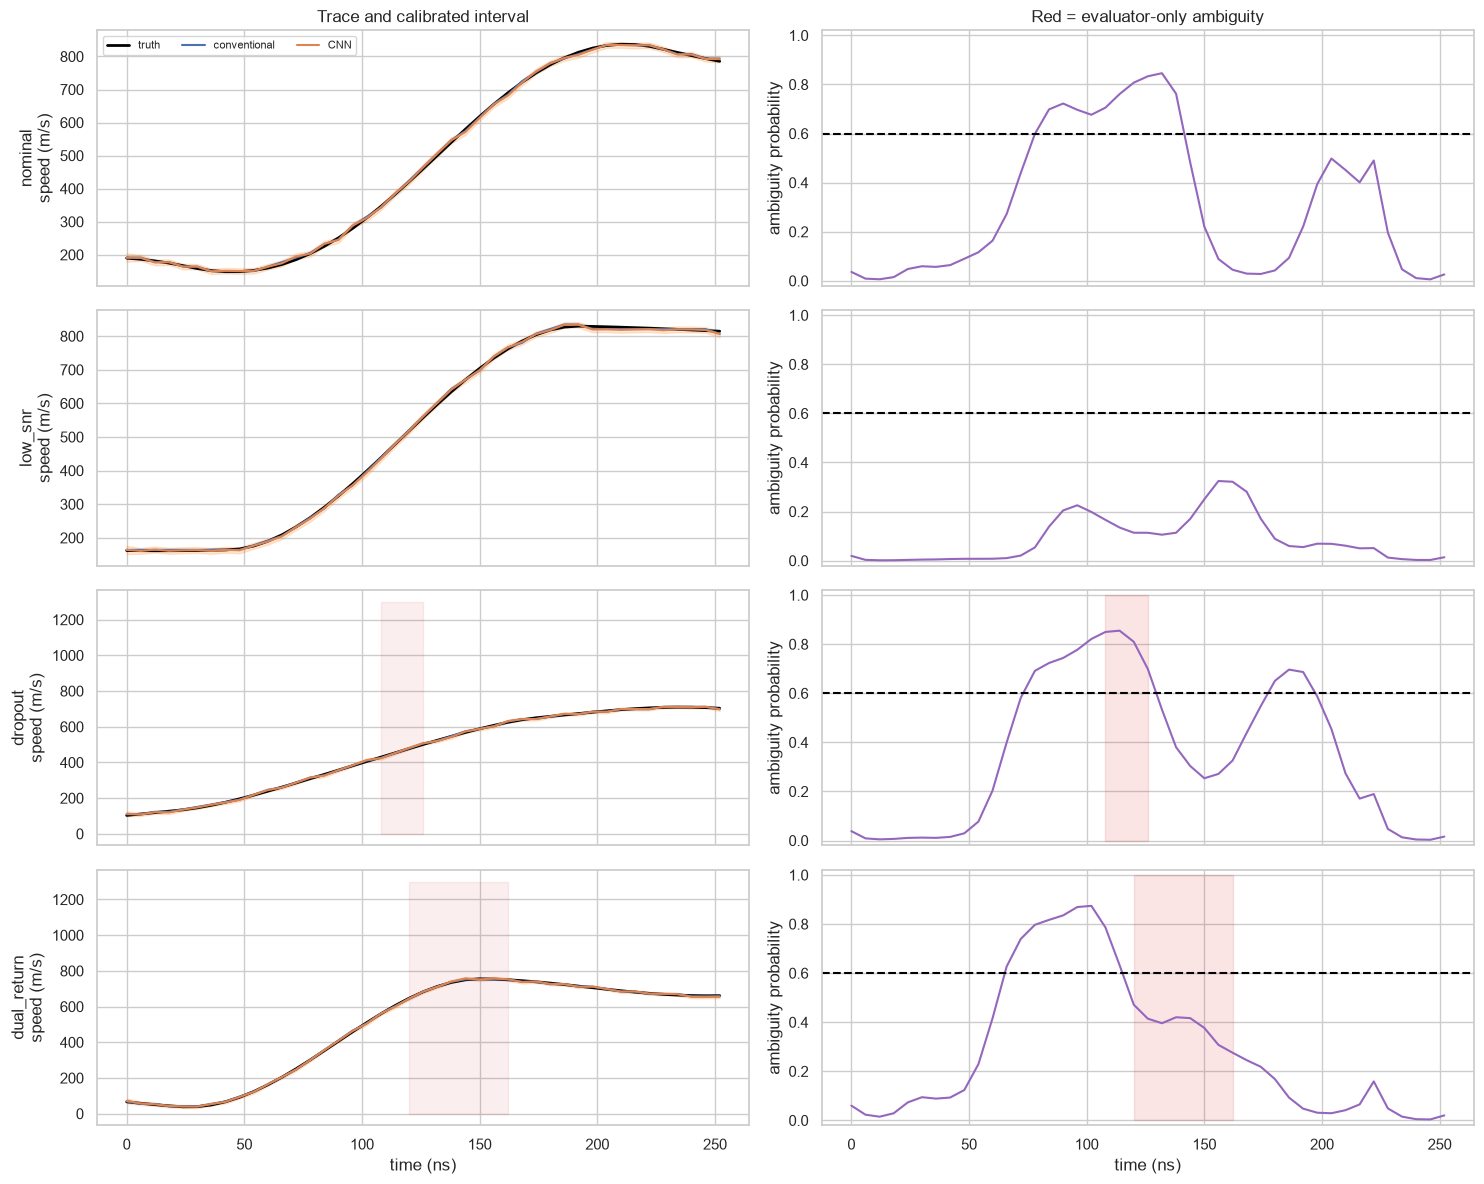

In [9]:
fig,axes=plt.subplots(1,3,figsize=(16,4))
sns.barplot(data=cal_shots.groupby(['regime','method']).MAE.mean().reset_index(),
            x='regime',y='MAE',hue='method',ax=axes[0])
axes[0].set_title('Calibration velocity error'); axes[0].tick_params(axis='x',rotation=20)
axes[1].plot(100*cal_risk.abstained_fraction,cal_risk.retained_MAE,'o-',label='MAE')
axes[1].plot(100*cal_risk.abstained_fraction,cal_risk.retained_p95,'o-',label='p95')
axes[1].set(xlabel='highest-risk usable frames abstained (%)',ylabel='error (m/s)',title='Uncertainty ranking'); axes[1].legend()
axes[2].plot(threshold_search.usable_false_alarm,threshold_search.recall)
axes[2].scatter([chosen.usable_false_alarm],[chosen.recall],s=80,color='tab:red',label='selected')
axes[2].set(xlabel='usable false-alarm rate',ylabel='ambiguity recall',title='Ambiguity operating curve'); axes[2].legend()
plt.tight_layout(); plt.show()

fig,axes=plt.subplots(4,2,figsize=(15,12),sharex='col')
for row,regime in enumerate(REGIMES):
    ex=cal_examples[regime]; x=ex['time']*1e9; band=1.96*SIGMA_SCALE*ex['raw_sigma']
    axes[row,0].plot(x,ex['truth'],color='black',linewidth=2,label='truth')
    axes[row,0].plot(x,ex['continuity'],label='conventional'); axes[row,0].plot(x,ex['cnn'],label='CNN')
    axes[row,0].fill_between(x,ex['cnn']-band,ex['cnn']+band,color='tab:orange',alpha=.18)
    axes[row,0].fill_between(x,0,MAX_SPEED,where=ex['amb'],color='tab:red',alpha=.08)
    axes[row,0].set_ylabel(f'{regime}\nspeed (m/s)')
    axes[row,1].plot(x,ex['ambiguity_prob'],color='tab:purple')
    axes[row,1].axhline(AMBIGUITY_THRESHOLD,color='black',linestyle='--')
    axes[row,1].fill_between(x,0,1,where=ex['amb'],color='tab:red',alpha=.12)
    axes[row,1].set_ylim(-.02,1.02); axes[row,1].set_ylabel('ambiguity probability')
axes[0,0].legend(ncol=3,fontsize=8); axes[-1,0].set_xlabel('time (ns)'); axes[-1,1].set_xlabel('time (ns)')
axes[0,0].set_title('Trace and calibrated interval'); axes[0,1].set_title('Red = evaluator-only ambiguity')
plt.tight_layout(); plt.show()

## 5. Frozen v2 acceptance gates

These gates must be fixed before setting `OPEN_LOCKED_TEST=True`.

1. CNN shot-mean MAE may not exceed continuity MAE by more than **1 m/s in any regime**.
2. 95% interval coverage must be **90%–99% in every regime**.
3. Mean 95% interval width must remain at or below **30 m/s**.
4. Ambiguity recall must be at least **80%**.
5. Usable-frame ambiguity false alarms must be at or below **20%**.
6. Rejecting the 10% of usable frames with greatest uncertainty must reduce retained MAE by at least **20%**.

The last gate may reveal that error ranking is structurally difficult when most usable-frame error comes from nearly uniform velocity-bin quantization. A failure remains evidence; the threshold is not relaxed after seeing the locked result.

In [10]:
MAX_REGIME_DEGRADATION=1.0
COVERAGE_RANGE=(.90,.99)
MAX_MEAN_INTERVAL_WIDTH=30.0
MIN_AMBIGUITY_RECALL=.80
MAX_USABLE_FALSE_ALARM=.20
MIN_MAE_REDUCTION_AT_10PCT_ABSTENTION=.20

if not OPEN_LOCKED_TEST:
    print('V2 LOCKED TEST REMAINS CLOSED:',LOCKED_TEST_ID)
else:
    locked_shots,locked_frames,locked_examples=evaluate_shots(locked,best['model'])
    locked_frames['calibrated_sigma']=locked_frames.raw_sigma*SIGMA_SCALE
    locked_velocity=locked_shots.groupby(['regime','method'])[['MAE','bias','p95_abs_error']].mean().round(2)
    locked_interval=(locked_frames.loc[~locked_frames.ambiguous].assign(
        covered=lambda d:np.abs(d.cnn-d.truth)<=1.96*d.calibrated_sigma,
        width_95=lambda d:2*1.96*d.calibrated_sigma)
        .groupby('regime')[['covered','width_95']].mean().rename(columns={'covered':'coverage_95'}))
    amb=ambiguity_metrics(locked_frames,AMBIGUITY_THRESHOLD); locked_risk=risk_curve(locked_frames)
    full=float(locked_risk.loc[locked_risk.retained_fraction==1,'retained_MAE'].iloc[0])
    kept90=float(locked_risk.loc[locked_risk.retained_fraction==.9,'retained_MAE'].iloc[0])
    reduction=(full-kept90)/full
    means=locked_shots.groupby(['regime','method']).MAE.mean().unstack()
    degradation=float((means['residual CNN']-means['continuity']).max())
    gates=pd.DataFrame([
        {'gate':'all-regime velocity degradation <= 1 m/s','value':degradation,'passed':degradation<=MAX_REGIME_DEGRADATION},
        {'gate':'all-regime coverage within 90%-99%','value':locked_interval.coverage_95.min(),'passed':locked_interval.coverage_95.between(*COVERAGE_RANGE).all()},
        {'gate':'mean interval width <= 30 m/s','value':locked_interval.width_95.mean(),'passed':locked_interval.width_95.mean()<=MAX_MEAN_INTERVAL_WIDTH},
        {'gate':'ambiguity recall >= 80%','value':amb['recall'],'passed':amb['recall']>=MIN_AMBIGUITY_RECALL},
        {'gate':'usable ambiguity false alarm <= 20%','value':amb['usable_false_alarm'],'passed':amb['usable_false_alarm']<=MAX_USABLE_FALSE_ALARM},
        {'gate':'10% abstention reduces MAE >= 20%','value':reduction,'passed':reduction>=MIN_MAE_REDUCTION_AT_10PCT_ABSTENTION},
    ])
    print('V2 LOCKED TEST CONSUMED:',LOCKED_TEST_ID)
    print('Velocity errors'); display(locked_velocity)
    print('Intervals by regime'); display(locked_interval.round(3))
    print('Ambiguity:',{k:round(v,3) for k,v in amb.items()})
    print('Risk/coverage'); display(locked_risk.round(3))
    print('Frozen gates'); display(gates.round(3))
    print('OVERALL:','PASS' if gates.passed.all() else 'FAIL')

V2 LOCKED TEST CONSUMED: pdv-robust-v2-seeds-40000-40063
Velocity errors


MAE  bias  p95_abs_error
regime      method                                 
dropout     continuity    3.50  0.19           6.80
            peak          3.50  0.19           6.80
            residual CNN  3.77 -0.20           7.77
dual_return continuity    3.60  0.36           6.80
            peak          3.60  0.36           6.80
            residual CNN  3.74  0.06           7.66
low_snr     continuity    3.82  0.24           7.88
            peak          3.82  0.24           7.88
            residual CNN  4.09 -0.79           9.01
nominal     continuity    3.51  0.19           6.94
            peak          3.51  0.19           6.94
            residual CNN  3.70 -0.24           8.04

Intervals by regime


,coverage_95,width_95
regime,,
dropout,0.977,17.716999
dual_return,0.980,17.723000
low_snr,0.945,17.568001
nominal,0.972,17.809000


Ambiguity: {'recall': 0.755, 'false_confidence': 0.245, 'usable_false_alarm': 0.156}
Risk/coverage


,retained_fraction,abstained_fraction,retained_MAE,retained_p95
0,1.00,0.00,3.832,8.332
1,0.95,0.05,3.736,8.098
2,0.90,0.10,3.747,8.091
3,0.80,0.20,3.773,8.093
4,0.70,0.30,3.758,8.041
5,0.50,0.50,3.735,7.984


Frozen gates


,gate,value,passed
0,all-regime velocity degradation <= 1 m/s,0.268,True
1,all-regime coverage within 90%-99%,0.945,True
2,mean interval width <= 30 m/s,17.704,True
3,ambiguity recall >= 80%,0.755,False
4,usable ambiguity false alarm <= 20%,0.156,True
5,10% abstention reduces MAE >= 20%,0.022,False


OVERALL: FAIL


### V2 locked-test result

The targeted ambiguity training produced a real improvement across separately seeded tests: ambiguity recall increased from **0% in v1** to **75.5% in v2**, while usable-frame false alarms increased from 0% to **15.6%**. Because v1 and v2 use different locked seeds, treat this as evidence of improvement rather than a paired comparison. V2 narrowly missed its frozen 80% recall requirement.

Every regime passed the 90%–99% interval-coverage gate; the worst was low SNR at **94.5%**. Mean interval width was **17.7 m/s**, below the 30 m/s limit. The CNN remained within the allowed velocity-degradation tolerance, although it was slightly worse than the conventional estimator in all four regimes.

Uncertainty ranking did not improve: rejecting the highest-risk 10% reduced MAE by only **2.2%**, compared with the required 20%. This supports the hypothesis that most remaining usable-frame error is not predictable from the current features, loss, and STFT resolution. The next experiment should measure identifiability before adding model size.

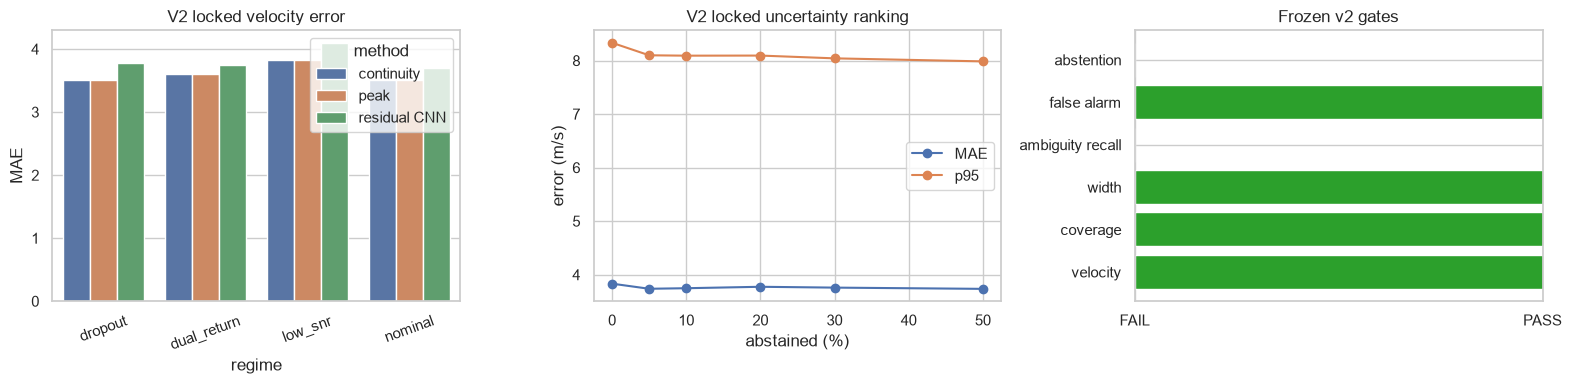

In [11]:
if OPEN_LOCKED_TEST:
    fig,axes=plt.subplots(1,3,figsize=(16,4))
    sns.barplot(data=locked_shots.groupby(['regime','method']).MAE.mean().reset_index(),
                x='regime',y='MAE',hue='method',ax=axes[0])
    axes[0].set_title('V2 locked velocity error'); axes[0].tick_params(axis='x',rotation=20)
    axes[1].plot(100*locked_risk.abstained_fraction,locked_risk.retained_MAE,'o-',label='MAE')
    axes[1].plot(100*locked_risk.abstained_fraction,locked_risk.retained_p95,'o-',label='p95')
    axes[1].set(xlabel='abstained (%)',ylabel='error (m/s)',title='V2 locked uncertainty ranking'); axes[1].legend()
    axes[2].barh(np.arange(len(gates)),gates.passed.astype(int),
                 color=['tab:green' if x else 'tab:red' for x in gates.passed])
    axes[2].set_yticks(np.arange(len(gates)),['velocity','coverage','width','ambiguity recall','false alarm','abstention'])
    axes[2].set_xlim(0,1); axes[2].set_xticks([0,1],['FAIL','PASS']); axes[2].set_title('Frozen v2 gates')
    plt.tight_layout(); plt.show()

## 6. Interpretation and next experiment

Compare v2 with v1 using the same metric definitions, while remembering that their locked cases use different seeds. The cleanest improvement target is ambiguity recall: v1 achieved 0% with a 0% false-alarm rate. Report both numbers together.

If uncertainty coverage passes but selective abstention fails again, do not assume a larger CNN will fix it. Examine whether the usable-frame errors are predictable from the allowed measurements. Uniform STFT-bin quantization error may be irreducible at the selected resolution. A higher-resolution estimator, sub-bin interpolation, or a changed decision target may be more appropriate.

Nothing in this notebook infers melting or identifies ETI, MRTI, or driver–liner coupling.

## Remaining work

- [x] Preserve the user's eight-seed notebook and the consumed v1 evaluation.
- [x] Separate tuning from uncertainty/threshold calibration.
- [x] Weight rare ambiguous frames and oversample relevant training regimes.
- [x] Add uncertainty-ranking supervision.
- [x] Replace the overall coverage gate with per-regime coverage gates.
- [ ] Verify the dynamic-programming tracker on a hand-constructed spectrogram.
- [ ] Add an independently implemented forward generator.
- [ ] Add timing, wavelength, bandwidth, saturation, and clock uncertainty.
- [ ] Test one immutable real waveform with documented provenance.